In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns
from diisco import names, DIISCO
import torch

timepoints = np.array([0, 5, 10, 15, 20, 25])
signal = np.array([0,0,1,1,1,1])

# 0 affected by: 2 pos
# 1 affected by: 0 pos
# 2 affected by: 1 neg
data = np.stack([[.2, .2, .6],
        [.2, .4, .4],
        [.25, .6, .15],
        [.3, .6, .1],
        [.4, .6, 0],
        [.45, .8, 0]], axis=0)
lambda_matrix = np.zeros((3, 3))
lambda_matrix[0,1] = 1
lambda_matrix[0,2] = 1
lambda_matrix[1,2] = 1
lambda_matrix[1,0] = 1
lambda_matrix[2,0] = 1
lambda_matrix[2,1] = 1

lambda_matrix = lambda_matrix.T
print(lambda_matrix)

[[0. 1. 1.]
 [1. 0. 1.]
 [1. 1. 0.]]


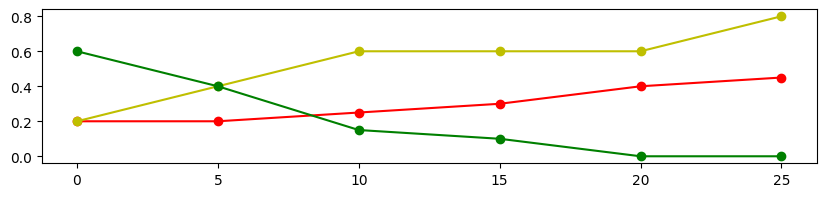

In [2]:
plt.figure(figsize = (10,2))
plt.plot(timepoints, data[:,0], '-ro')
plt.plot(timepoints, data[:,1], '-yo')
plt.plot(timepoints, data[:,2], '-go')
plt.show()

In [3]:
X = timepoints.reshape(-1, 1)
print(X)

X2 = signal.reshape(-1,1)
lengthscale_f1 = np.mean(np.abs(X - X.T))
print(lengthscale_f1)
lengthscale_f2 = np.mean(np.abs(X2 - X2.T))
print(lengthscale_f2)

j = int(lambda_matrix.sum(axis=1).max())
lengthscale_W = max([X[i, 0] - X[i-j+1, 0] for i in range(j-1, X.shape[0])])
print(lengthscale_W)

[[ 0]
 [ 5]
 [10]
 [15]
 [20]
 [25]]
9.722222222222221
0.4444444444444444
5


In [4]:
print(X.shape)
timepoints = torch.tensor(X).float()
proportions = torch.tensor(data).float()
lambda_prior = torch.tensor(lambda_matrix).float()
signal_t = torch.tensor(signal.reshape(-1, 1)).float()
# z score the proportions
proportions_mean = proportions.mean(dim=0)
proportions_std = proportions.std(dim=0)
proportions = (proportions - proportions_mean)/ (proportions_std)

(6, 1)


In [5]:
print(signal_t)

tensor([[0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.]])


In [6]:
hyper_init_vals = {
    names.LENGTHSCALE_F_1: lengthscale_f1,
    names.LENGTHSCALE_F_2: lengthscale_f2,
    names.LENGTHSCALE_W: lengthscale_W,
    names.SIGMA_F: 0.5,
    names.VARIANCE_F: 1,
    names.SIGMA_W: 0.1,
    names.VARIANCE_W: 1,
    names.SIGMA_Y: 0.5,
}
print(hyper_init_vals)

{'lengthscale_f_1': 9.722222222222221, 'lengthscale_f_2': 0.4444444444444444, 'lengthscale_w': 5, 'sigma_f': 0.5, 'variance_f': 1, 'sigma_w': 0.1, 'variance_w': 1, 'sigma_y': 0.5}


In [7]:
def unscale(proportions, cluster_index): 
    return np.clip(proportions * 
                   proportions_std.detach().numpy()[cluster_index] + 
                   proportions_mean.detach().numpy()[cluster_index], 
                   0, None)

(6, 3)
Set prior parameters: mean tensor([[[-0.8425],
         [-0.8479],
         [-0.3536],
         [ 0.1544],
         [ 0.7832],
         [ 1.1597]],

        [[-1.1566],
         [-0.8334],
         [ 0.2104],
         [ 0.3458],
         [ 0.6010],
         [ 0.8546]],

        [[ 1.2034],
         [ 0.9251],
         [-0.2355],
         [-0.5046],
         [-0.7217],
         [-0.7628]]]), cov tensor([[[ 0.1517,  0.0689,  0.0007, -0.0010, -0.0004,  0.0003],
         [ 0.0689,  0.1515,  0.0024,  0.0010, -0.0002, -0.0003],
         [ 0.0007,  0.0024,  0.1493,  0.0726,  0.0066, -0.0144],
         [-0.0010,  0.0010,  0.0726,  0.0991,  0.0670,  0.0065],
         [-0.0004, -0.0002,  0.0066,  0.0670,  0.0991,  0.0726],
         [ 0.0003, -0.0003, -0.0144,  0.0065,  0.0726,  0.1495]],

        [[ 0.1517,  0.0689,  0.0007, -0.0010, -0.0004,  0.0003],
         [ 0.0689,  0.1515,  0.0024,  0.0010, -0.0002, -0.0003],
         [ 0.0007,  0.0024,  0.1493,  0.0726,  0.0066, -0.0144],
        

100%|██████████| 1000/1000 [00:01<00:00, 752.04it/s]


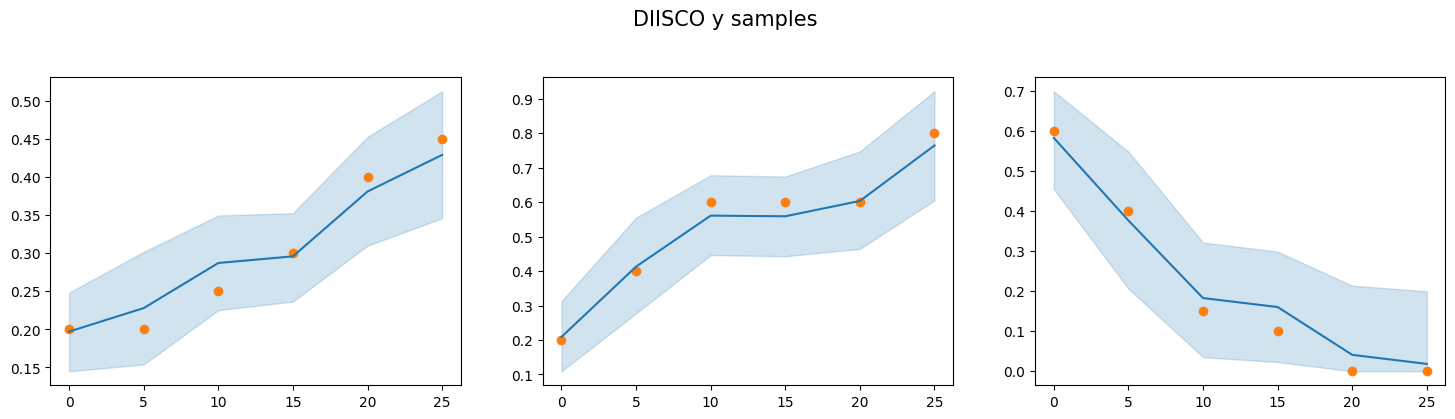

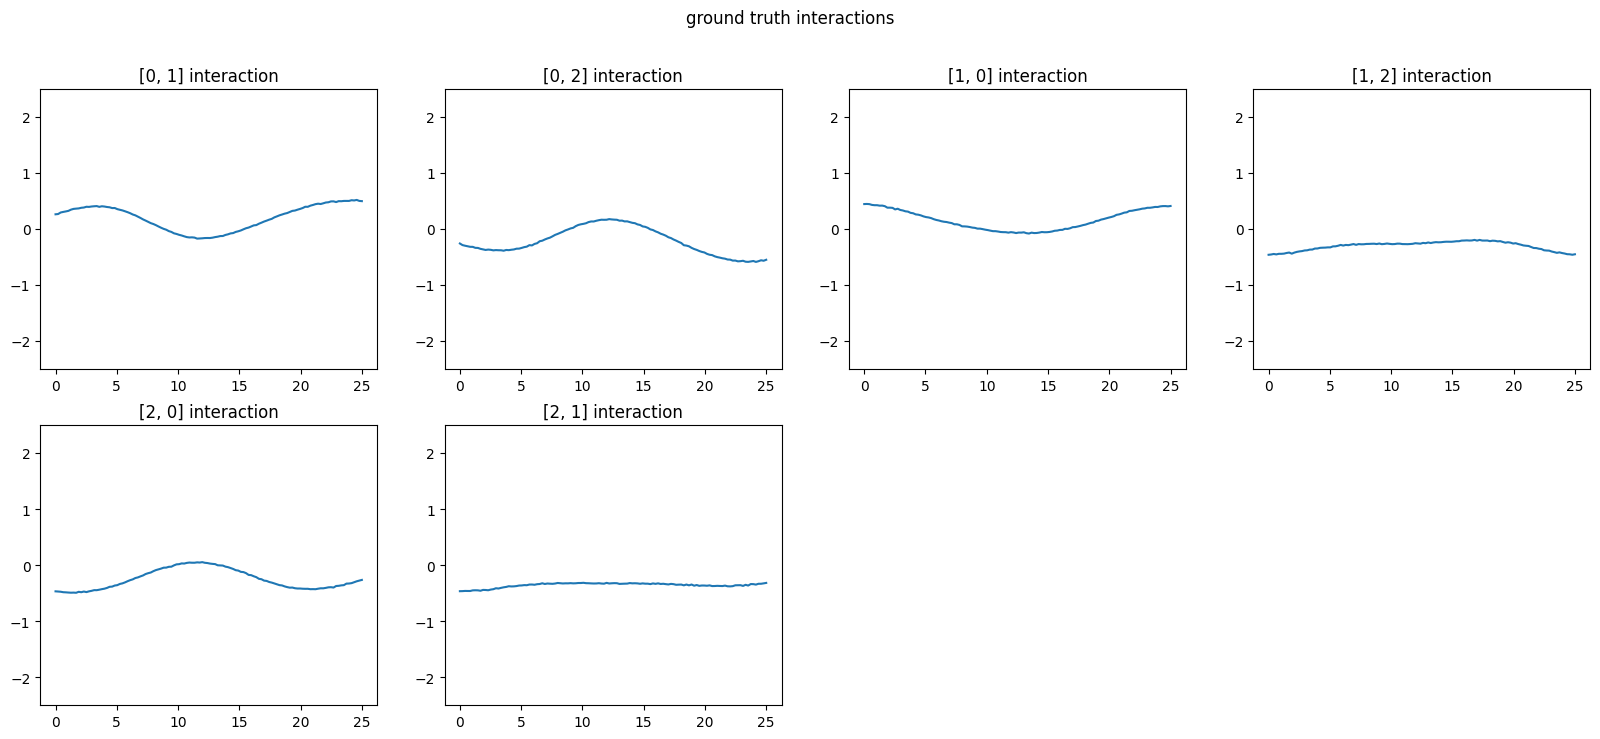

In [8]:
print(data.shape)
# lambda set here
model = DIISCO(lambda_matrix=lambda_prior, hypers_init_vals=hyper_init_vals, verbose=True, verbose_freq=100)

#model.fit_and_set_f_prior_params(timepoints=timepoints, proportions=proportions, hypers=model.hypers_init_vals)
model.fit_and_set_f_prior_params(timepoints=timepoints, signals=signal_t, proportions=proportions, hypers=model.hypers_init_vals)
#model.fit_and_set_w_prior_params(timepoints=timepoints, hypers=model.hypers_init_vals)    
#model.fit(timepoints=timepoints, proportions=proportions,  n_iter=15000, lr=0.00005, guide="MultivariateNormalFactorized")
model.fit(timepoints=timepoints, signals=signal_t, proportions=proportions,  n_iter=15000, lr=0.00005, guide="MultivariateNormalFactorized")
        
true_observations = data
predicted_observations = model.sample_observed_proportions(n_samples=1000).detach()
print(predicted_observations.shape)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i in range(3):
    cell_type_samples = predicted_observations[:, :, i]
    mean = unscale(cell_type_samples.mean(axis=0), i)
    percentile_75 = unscale(np.percentile(cell_type_samples, 84, axis=0), i)
    percentile_25 = unscale(np.percentile(cell_type_samples, 16, axis=0), i)
    axes[i].plot(timepoints, mean, c='tab:blue')
    axes[i].fill_between(timepoints.squeeze(), percentile_25, percentile_75, color='tab:blue', alpha=0.2)
    axes[i].scatter(timepoints, unscale(proportions[:, i], i), c='tab:orange')

plt.suptitle('DIISCO y samples', fontsize=15, y=1.05)
    
predict_timepoints = torch.linspace(timepoints.min(), timepoints.max(), 120).reshape(-1, 1)
predict_signals = np.concatenate((np.zeros(40), np.ones(80)), axis=0)
predict_signals = torch.tensor(predict_signals.reshape(-1, 1)).float()

samples = model.sample(predict_timepoints,
                       predict_signals,
                       n_samples=1000, 
                       n_samples_per_latent=10,
                       include_emission_variance=True)

W_samples_predict = samples['W']
f_samples_predict = samples['F']
y_samples_predict = samples['Y']
        
interaction_plots = []
for i in range(3):
    for j in range(3):
        # print(i,j)
        if i == j: continue
        w_pred = W_samples_predict[:, :,i, j].detach().numpy()
        if np.max(np.abs(w_pred)) > 0.005: 
            interaction_plots.append([i,j])
                    
n = len(interaction_plots); max_cols = 4
nrows = int(np.ceil(n / max_cols)); ncols = int(min((max_cols, n)))
fig = plt.figure(figsize=[5 * ncols, 4 * nrows])
for i,interaction in enumerate(interaction_plots):
    ax = fig.add_subplot(nrows, ncols, i+1)
    #ax.scatter(timepoints, proteins[:, interaction[0], interaction[1]], c='tab:orange')
    ax.plot(predict_timepoints, 
                    W_samples_predict[:, :,interaction[0], interaction[1]].mean(axis=0))
    ax.set_title(f'{interaction} interaction')
    ax.set_ylim(-2.5,2.5)
plt.suptitle("ground truth interactions")
plt.show()

Text(0.5, 1.05, 'DIISCO predicted interactions ($\\hat{W}_{avg})$')

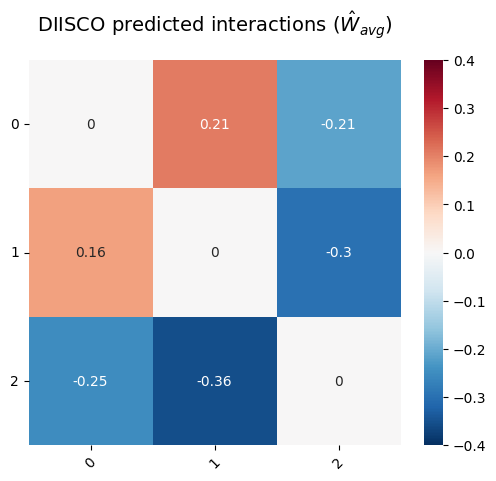

In [9]:
import seaborn as sns

plt.figure(figsize=(6, 5))
W_avg_over_time = W_samples_predict.mean(axis=(0, 1)).detach().numpy()
ax = sns.heatmap(W_avg_over_time, cmap="RdBu_r", annot=True, 
                 vmax=0.4, vmin=-0.4, center=0)
plt.yticks(rotation=0)
plt.xticks(rotation=45)
plt.title('DIISCO predicted interactions ($\hat{W}_{avg})$', fontsize=14, y=1.05)
# 0 affected by: 2 pos
# 1 affected by: 0 pos
# 2 affected by: 0 neg

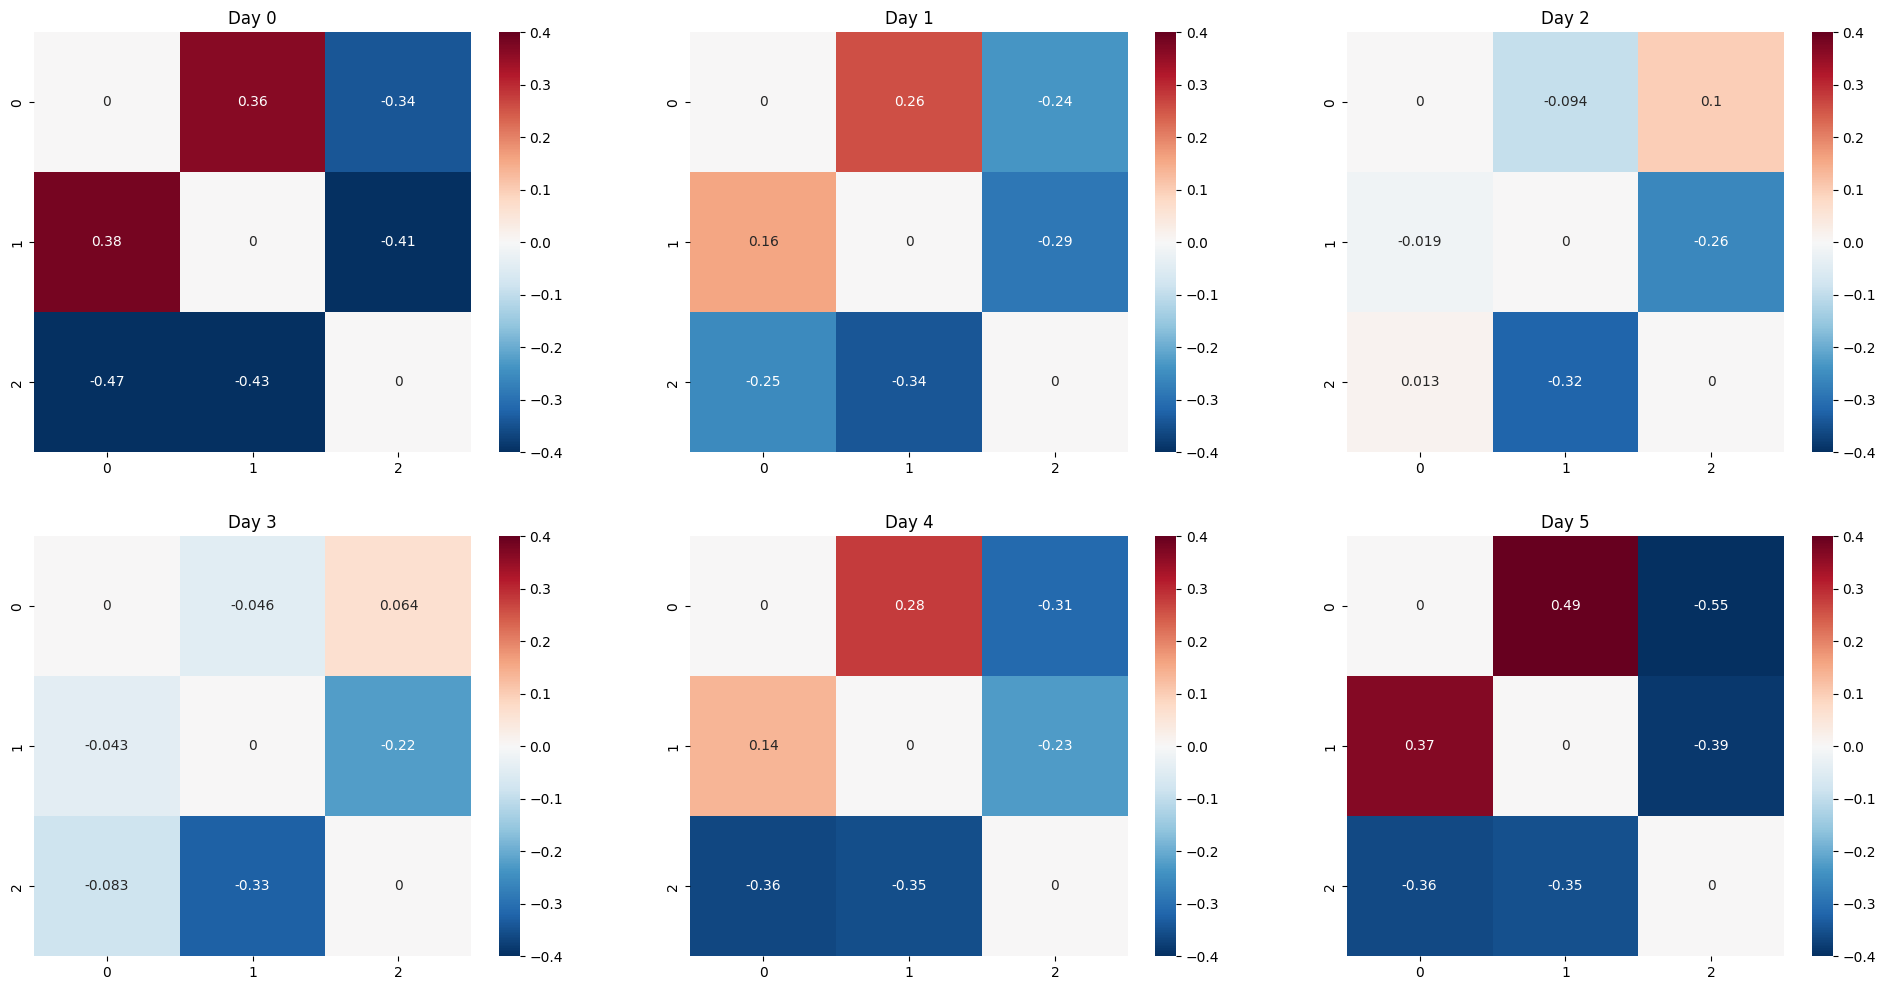

In [10]:
W_avg_per_timepoint = W_samples_predict.mean(axis=(0)).detach().numpy()
W_avg_1 = W_avg_per_timepoint[0:20].mean(axis=(0))
W_avg_2 = W_avg_per_timepoint[20:40].mean(axis=(0))
W_avg_3 = W_avg_per_timepoint[40:60].mean(axis=(0))
W_avg_4 = W_avg_per_timepoint[60:80].mean(axis=(0))
W_avg_5 = W_avg_per_timepoint[80:100].mean(axis=(0))
W_avg_6 = W_avg_per_timepoint[100:120].mean(axis=(0))

fig = plt.figure(figsize=(24, 12))
(row0,row1) = fig.subplots(2, 3)
sns.heatmap(W_avg_1, cmap="RdBu_r", annot=True, vmax=0.4, vmin=-0.4, center=0, ax=row0[0])
row0[0].set_title("Day 0")

sns.heatmap(W_avg_2, cmap="RdBu_r", annot=True, vmax=0.4, vmin=-0.4, center=0, ax=row0[1])
row0[1].set_title("Day 1")

sns.heatmap(W_avg_3, cmap="RdBu_r", annot=True, vmax=0.4, vmin=-0.4, center=0, ax=row0[2])
row0[2].set_title("Day 2")

sns.heatmap(W_avg_4, cmap="RdBu_r", annot=True, vmax=0.4, vmin=-0.4, center=0, ax=row1[0])
row1[0].set_title("Day 3")

sns.heatmap(W_avg_5, cmap="RdBu_r", annot=True, vmax=0.4, vmin=-0.4, center=0, ax=row1[1])
row1[1].set_title("Day 4")

sns.heatmap(W_avg_6, cmap="RdBu_r", annot=True, vmax=0.4, vmin=-0.4, center=0, ax=row1[2])
row1[2].set_title("Day 5")

plt.show()